In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('omega_class_moments_N1e6.csv')
print(df)


 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 
9 zeta 1000000 884001.871616 500.0 21169.883300 264592.121329 
10 L(Δ) 1000000 2676.505424 500.0 1098.486340 781.974004 
11 L_DH 1000000 2432.632471 500.0 663.110599 873.431509 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451

In [2]:
print("L_functions:", df['L_function'].unique())
print("N values per function:")
print(df.groupby('L_function')['N_terms'].apply(list))


L_functions: ['zeta' 'L(Δ)' 'L_DH']
N values per function:
L_function
L(Δ) [10000, 50000, 100000, 1000000]
L_DH [10000, 50000, 100000, 1000000]
zeta [10000, 50000, 100000, 1000000]
Name: N_terms, dtype: object


In [3]:
import os
files = os.listdir('.')
print(files)


['.kernel_llm_logs_1.txt', '.prompts', 'memory', '.config', 'ancova_zeta_vs_ldh_summary.csv', 'omega_class_moments_N1e6.csv']


In [4]:
# Verify by checking ancova_zeta_vs_ldh_summary.csv
df_anc = pd.read_csv('ancova_zeta_vs_ldh_summary.csv')
print(df_anc.to_string())


 omega_class_k slope_zeta slope_L_DH diff (L_DH - ζ) p_inter (ζ vs L_DH) significant_p<0.05 R^2 slope_L(Δ) slope_L_DH (prev) diff (L_DH - L(Δ)) p_inter (L(Δ) vs L_DH)
0 1 5.909832 0.170682 -5.739150 0.007397 True 0.980853 0.289281 0.170682 -0.118598 0.008824
1 2 9.179181 0.480114 -8.699067 0.000230 True 0.997735 0.798012 0.480114 -0.317898 0.000136
2 3 11.259969 1.565975 -9.693995 0.000035 True 0.999398 2.022539 1.565975 -0.456564 0.009348
3 4 14.830843 3.065841 -11.765001 0.000003 True 0.999771 4.821428 3.065841 -1.755587 0.047471


In [5]:
import subprocess
# Check broader filesystem for the file
result = subprocess.run(['find', '/workspace', '-name', '*lchi*', '-o', '-name', '*chi*zeros*'], 
 capture_output=True, text=True, timeout=30)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr[:500])


STDOUT: 
STDERR: find: ‘/workspace/lost+found’: Permission denied



In [6]:
# Broader search
result = subprocess.run(['find', '/workspace', '-maxdepth', '3', '-name', '*.npy'], 
 capture_output=True, text=True, timeout=30)
print("NPY files:", result.stdout)

result = subprocess.run(['find', '/', '-maxdepth', '4', '-name', 'lchi_zeros*', '-not', '-path', '*/proc/*'],
 capture_output=True, text=True, timeout=30)
print("lchi search:", result.stdout)
print("err:", result.stderr[:300])


NPY files: 


lchi search: 
err: find: ‘/app’: Permission denied
find: ‘/etc/cron.d’: Permission denied
find: ‘/etc/ssh’: Permission denied
find: ‘/etc/polkit-1/rules.d’: Permission denied
find: ‘/etc/ssl/private’: Permission denied
find: ‘/proc/1/fd’: Permission denied
find: ‘/proc/1/ns’: Permission denied
find: ‘/proc/17/fd’: Per


In [7]:
# The lchi_zeros file is not present. Per dataset description it should exist but it is not in our workspace.
# Per the Core Principles (no fabrication), I must report this limitation honestly.
# 
# However, the research objective is to compare L(χ₄ mod 5) vs L_DH using ANCOVA on the omega-class moments.
# The required input (lchi rows in omega_class_moments_N1e6.csv OR raw lchi zeros) is missing.
# 
# Options:
# (1) Compute lchi zeros from scratch -- would need first 5000 zeros at high precision. 
# This is feasible with mpmath but expensive. Then need to compute NUFFT integration for 
# N up to 10^6 of |S_k(t)|^2 partitioned by omega(n). This is a substantial computation
# and would itself need careful validation.
# (2) Report that lchi data is unavailable, document what we have, and present the partial
# comparison.
#
# Given the runtime budget (3600s) and the complexity (computing 5000 high-precision zeros of a 
# Dirichlet L-function via mpmath, plus NUFFT moment integration for 4 N values, plus PARI mfDelta-like
# basis), option (1) is risky but feasible to *attempt* for the zeros. The NUFFT integration with 
# the validation procedure used previously (NUFFT on t∈[0,500] with dt=0.025) is straightforward.
#
# Actually the key insight: We need the *omega-class moment data*, not the zeros directly. 
# Looking at omega_class_moments_N1e6.csv: the data is M_k = integrals of |S_k(t)|^2 from t=0 to 500.
# This does NOT require the zeros! It requires the Dirichlet series coefficients of L(χ₄ mod 5),
# which are simply χ₄(n) for n mod 5 (where χ₄ is the unique non-trivial real character mod 5... 
# wait, there's the Legendre symbol-like character).
#
# Wait — looking more carefully: M_total for zeta is ~14000 at N=10^4, growing to ~884000 at N=10^6.
# For L(Δ) and L_DH, M_total is in the thousands. 
# So zeta grows roughly linearly with N (~N), while L(Δ) and L_DH saturate. 
# This is because zeta has coefficient a_n=1 for all n, so sum |1|^2 ~ N, while L(Δ) has 
# Ramanujan-bounded coefficients with cancellation, and L_DH is a linear combination with mod-5 
# character zeroing out 1/5 of terms.
#
# For L(χ₄ mod 5), I need the character mod 5 -- this is a Dirichlet character. The non-trivial 
# characters mod 5: there are φ(5)=4. The Legendre symbol (n/5) takes values {1,-1,1,-1,0} for 
# n=1,2,3,4,5 mod 5. The character χ_4 mod 5 in some notation refers to the order-4 character.
# 
# But I don't know the EXACT integration parameters used (t-range, dt, basis function) -- 
# the description says "NUFFT-based numerical integration of |S_k(t)|² on t∈[0,500] with dt=0.025"
# 
# However, fundamentally: the moments we need depend on coefficients only (not zeros).
# We could compute these from scratch. Let me check if this is feasible.

# First, let me think about |S_k(t)|^2 where S_k(t) = sum_{n<=N, omega(n)=k} a_n n^{-1/2-it}
# Then integral_0^T |S_k(t)|^2 dt -- by the mean value theorem of Dirichlet polynomials,
# this is approximately T * sum_n |a_n|^2 / n (for terms with omega=k, n<=N) + cross terms.

# Actually let me re-examine: M_k for k=0 is constant 500 for all three functions and all N.
# That's because omega(n)=0 means n=1, contributing |a_1|^2/1 * T_window = 1 * 500 = 500.
# This confirms M_k = T * sum_{omega(n)=k, n<=N} |a_n|^2 / n + small off-diagonal.
# For T=500, integral over t in [0,500].

# So the analysis is straightforward: M_k(N) ≈ T * sum_{omega(n)=k, n<=N} |a_n|^2 / n (for T=500)

# For L(χ4 mod 5): a_n = χ(n), so |a_n|^2 = 1 if gcd(n,5)=1, else 0.
# Thus M_k ≈ T * sum_{omega(n)=k, n<=N, gcd(n,5)=1} 1/n

# This is computable directly without NUFFT, since |χ(n)|^2 = indicator that gcd(n,5)=1.
# Similarly for zeta: a_n=1, |a_n|^2=1, so M_k(N) ≈ T * sum_{omega(n)=k, n<=N} 1/n
# Let me verify this matches the existing zeta data.

print("Verify by computing zeta M_k(N=10^4) ≈ 500 * sum_{omega(n)=k, n<=10^4} 1/n")


Verify by computing zeta M_k(N=10^4) ≈ 500 * sum_{omega(n)=k, n<=10^4} 1/n


In [8]:
import numpy as np
from sympy import factorint

def omega(n):
 """Number of distinct prime factors."""
 if n == 1:
 return 0
 return len(factorint(n))

# For small N, validate the relationship
N = 10000
T = 500
# Sieve omega
def omega_sieve(N):
 om = np.zeros(N+1, dtype=np.int32)
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 for p in range(2, N+1):
 if is_prime[p]:
 for m in range(p, N+1, p):
 om[m] += 1
 if m > p:
 is_prime[m] = False
 return om

om = omega_sieve(N)
print("omega distribution at N=10^4:", np.bincount(om))

# zeta M_k(N=10^4) prediction
inv_n = 1.0 / np.arange(1, N+1)
M_pred = {}
for k in range(5):
 mask = (om[1:] == k)
 M_pred[k] = T * np.sum(inv_n[mask])
mask_geq5 = (om[1:] >= 5)
M_pred['geq5'] = T * np.sum(inv_n[mask_geq5])

print("\nPredicted zeta M_k (using T*sum 1/n) at N=10^4:")
for k in range(5):
 print(f" M_{k} = {M_pred[k]:.4f}")
print(f" M_geq5 = {M_pred['geq5']:.4f}")

print("\nActual zeta M_k from CSV at N=10^4:")
row = df[(df['L_function']=='zeta') & (df['N_terms']==10000)].iloc[0]
print(f" M_0 = {row['M_0']:.4f}")
print(f" M_1 = {row['M_1']:.4f}")
print(f" M_2 = {row['M_2']:.4f}")
print(f" M_3 = {row['M_3']:.4f}")
print(f" M_4 = {row['M_4']:.4f}")
print(f" M_geq5 = {row['M_geq5']:.4f}")


omega distribution at N=10^4: [ 2 1280 4097 3695 894 33]

Predicted zeta M_k (using T*sum 1/n) at N=10^4:
 M_0 = 500.0000
 M_1 = 1626.8269
 M_2 = 1838.0539
 M_3 = 811.2544
 M_4 = 114.9707
 M_geq5 = 2.6972

Actual zeta M_k from CSV at N=10^4:
 M_0 = 500.0000
 M_1 = 1965.7470
 M_2 = 6483.5377
 M_3 = 4759.5681
 M_4 = 337.9224
 M_geq5 = 2.8352


In [9]:
# The simple diagonal T*sum |a_n|^2/n approximation underestimates M_k significantly.
# The off-diagonal contributions are non-negligible. So we cannot bypass the actual NUFFT computation
# without proper integration of |S_k(t)|^2.
# 
# Cross terms: integral_0^T (m/n)^{it} dt = (m/n)^{iT} ... real part gives sin/cos which doesn't 
# fully average away over finite T=500.
#
# Let me compute the actual integral exactly (analytically):
# |S_k(t)|^2 = sum_{m,n: omega(m)=omega(n)=k, m,n<=N} a_m conj(a_n) (n/m)^{it} / sqrt(mn)
# integral_0^T (n/m)^{it} dt = (n/m)^{iT} / (i log(n/m)) - 1/(i log(n/m)) (for m≠n)
# = [e^{iT log(n/m)} - 1] / (i log(n/m))
# For m=n: T.
#
# So M_k = T * diag + sum_{m≠n} a_m conj(a_n)/sqrt(mn) * [e^{iT log(n/m)} - 1] / (i log(n/m))
#
# This is exact analytically. For real a_n (and we'll be computing |S_k|^2 ∈ ℝ), pairing (m,n) and 
# (n,m) gives real sum. We can compute this directly without NUFFT for moderate N!
#
# But for N=10^6, there are ~10^12 pairs -- too many.
# 
# However, the existing data was computed with NUFFT and shows the off-diagonal contributions matter.
# Let me check at N=10^4 whether direct exact computation is feasible.

# For omega(n)=1 at N=10^4, there are 1280 such n's -> 1280^2 ≈ 1.6M pairs. Feasible.
# For omega(n)=2: 4097 -> 16.8M pairs. Tight but possible.
# For N=10^6, omega=2: ~2.7e5 numbers -> 7e10 pairs. Not feasible directly.

# Let me first verify by exact computation at N=10^4 against the CSV value.
import time

N = 10000
T = 500.0

# Get indices for each omega class
idx_by_omega = {k: np.where(om[1:N+1] == k)[0] + 1 for k in range(5)} # +1 since omega indexed from 1

# For zeta, a_n = 1
# Compute M_k = sum_{m,n: omega=k} (1/sqrt(mn)) * integral_0^T (n/m)^{it} dt
# = T*N_k_diag_sum + Re[sum_{m<n} 2/sqrt(mn) * (e^{iT log(n/m)} - 1)/(i log(n/m))]
# 
# Since |S_k|^2 is real, sum over all (m,n) gives real result.

def compute_M_k_exact_zeta(indices, T):
 """For zeta a_n=1, compute integral_0^T |S_k(t)|^2 dt exactly."""
 n_arr = np.asarray(indices, dtype=np.float64)
 # Diagonal: sum 1/n * T
 diag = T * np.sum(1.0 / n_arr)
 # Off-diagonal: only need m<n pairs, each contributes 2*Re part
 # We have potentially large array. Use outer products carefully.
 # Returns Im part calc: integral = (cos(T*L)-1)/L + sin(T*L)/L * i / 1 -- but real part:
 # [e^{iTL}-1]/(iL) = (sin(TL) - i(cos(TL)-1))/L * (1) ... let me redo
 # e^{iTL}/(iL) - 1/(iL) = (cos TL + i sin TL)/(iL) - 1/(iL)
 # = (sin TL - i cos TL)/L + i/L
 # = sin(TL)/L + i(1 - cos(TL))/L
 # So Re[integral_0^T (n/m)^{it} dt] = sin(TL)/L where L = log(n/m)
 # For m<n, L>0.
 # Then pair (m,n) and (n,m) contributes 2 * Re part * a_m conj(a_n)/sqrt(mn) = 2 * sin(TL)/L / sqrt(mn)
 # (since a_n real for zeta)
 
 off = 0.0
 nn = len(n_arr)
 # Process in blocks to manage memory: for each m, compute against all n > m
 for i in range(nn-1):
 m = n_arr[i]
 ns = n_arr[i+1:]
 L = np.log(ns / m)
 # avoid L=0 (shouldn't happen since distinct integers)
 re_int = np.sin(T * L) / L
 contrib = 2.0 * re_int / np.sqrt(m * ns)
 off += np.sum(contrib)
 return diag + off

# Test for k=1 (smallest non-trivial)
t0 = time.time()
M1_exact = compute_M_k_exact_zeta(idx_by_omega[1], T)
print(f"zeta M_1 (exact, N=10^4): {M1_exact:.4f} (CSV: 1965.747) time={time.time()-t0:.1f}s")


zeta M_1 (exact, N=10^4): 1965.7466 (CSV: 1965.747) time=0.0s


In [10]:
# Excellent! Exact computation matches CSV to 4 decimal places. So the methodology is:
# M_k = sum_{m,n: omega(m)=omega(n)=k, m,n<=N} a_m conj(a_n)/sqrt(mn) * integral_0^T (n/m)^{it} dt
#
# For L(χ4 mod 5), a_n = χ(n) where χ is the order-4 Dirichlet character mod 5.
# χ(n) values for n mod 5: χ(0)=0, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1.
# (For the order-4 character; the other character is its conjugate.)
#
# For |S_k(t)|^2 = S_k * conj(S_k), with complex coefficients a_n=χ(n):
# |S_k|^2 = sum_{m,n} a_m conj(a_n) (n/m)^{it}/sqrt(mn)
# Integral: real-valued (since |S_k|^2 is real and non-negative).
# integral_0^T = T*diag + Re[2 * sum_{m<n} a_m conj(a_n) * (sin(TL)+i(1-cos(TL)))/L / sqrt(mn)]
# = T*sum |a_n|^2/n + 2*Re[ sum_{m<n} a_m conj(a_n) * (sin(TL) + i(1-cos TL))/L / sqrt(mn) ]
# Let a_m conj(a_n) = α + iβ, then Re contribution = (α sin(TL) - β(1-cos TL))/L
# Then doubled.
#
# Now: a_m conj(a_n) for χ mod 5 (order-4): values in {0, ±1, ±i}.
# Since χ takes values {1, i, -1, -i, 0}, a_m conj(a_n) only depends on m,n mod 5.
# 
# Let me verify L_DH first — its character pattern is mod 5: 
# L_DH = L(s, χ) + c * L(s, χ̄) for some c, giving real coefficients that follow mod-5 pattern.
# Actually L_DH coefficients are real, with pattern (1, c, c̄, -1, 0) where c is complex. Hmm but the
# DH function has real coefficients. The standard pattern is:
# a_n where a_1=1, a_2=ξ, a_3=ξ̄, a_4=-1, a_5=0, and multiplicative, with ξ = (-1+i√(3-2√2))/√(2√2) 
# or something. Wait — actually Davenport-Heilbronn uses coefficient sequence with period 5:
# a_n for n≡1,2,3,4,0 mod 5 = 1, ξ, -ξ, -1, 0 with ξ = tan(θ)... let me check.
#
# Davenport-Heilbronn: f(s) = ξ L(s, χ) + L(s, χ̄), with ξ chosen so the functional equation holds 
# with sign +1 (rather than complex). The coefficients are real but not multiplicative.
# Specific value: ξ = (√(10-2√5) - 2)/(√5 - 1) ≈ 0.28469...
# Coefficient sequence (period 5): 1, ξ, -ξ, -1, 0 (real coefficients)
# So |a_n|^2 for L_DH = 1, ξ^2, ξ^2, 1, 0 (period 5).
#
# For L(χ4 mod 5) we just have χ(n) with order-4: a_n complex with |a_n|^2 = 1 if gcd(n,5)=1 else 0.
#
# Let me test reproducing L_DH M_1 at N=10^4 with the exact method:

xi = (np.sqrt(10 - 2*np.sqrt(5)) - 2) / (np.sqrt(5) - 1)
print(f"ξ_DH = {xi}")

# Period-5 coefficient pattern for L_DH
ldh_pattern = np.array([1.0, xi, -xi, -1.0, 0.0]) # for n mod 5 = 1,2,3,4,0

def a_ldh(n_arr):
 return ldh_pattern[n_arr % 5]

def compute_M_k_exact(indices, T, a_func):
 """Compute integral_0^T |S_k(t)|^2 dt exactly for real or complex coefficients a_n.
 a_func: callable taking integer array -> coefficient array (real or complex)."""
 n_arr = np.asarray(indices, dtype=np.int64)
 a_arr = a_func(n_arr) # may be complex
 n_f = n_arr.astype(np.float64)
 inv_sqrt_n = 1.0 / np.sqrt(n_f)
 
 # Diagonal
 diag = T * np.sum(np.abs(a_arr)**2 / n_f)
 
 off = 0.0 # accumulate real
 nn = len(n_arr)
 for i in range(nn-1):
 m = n_f[i]
 am = a_arr[i]
 ns = n_f[i+1:]
 an = a_arr[i+1:]
 L = np.log(ns / m)
 sinTL = np.sin(T * L)
 cosTL_m1 = np.cos(T * L) - 1.0 # so 1-cos = -cosTL_m1
 # a_m * conj(a_n) = ?
 prod = am * np.conj(an) # complex possibly
 # 2 * Re[prod * (sinTL/L + i*(-cosTL_m1)/L)] / sqrt(mn)
 # Re[prod * (X + iY)] = Re(prod)*X - Im(prod)*Y
 X = sinTL / L
 Y = -cosTL_m1 / L
 re_part = np.real(prod) * X - np.imag(prod) * Y
 contrib = 2.0 * re_part / np.sqrt(m * ns)
 off += np.sum(contrib)
 return diag + off

# Test L_DH M_1 at N=10^4
# Need omega=1 indices up to N=10^4
idx1 = idx_by_omega[1]
t0 = time.time()
M1_ldh = compute_M_k_exact(idx1, T=500.0, a_func=a_ldh)
print(f"L_DH M_1 (exact, N=10^4): {M1_ldh:.4f} (CSV: 618.4787) time={time.time()-t0:.1f}s")


ξ_DH = 0.28407904384041227
L_DH M_1 (exact, N=10^4): 611.2145 (CSV: 618.4787) time=0.1s


In [11]:
# Close but not exact (0.07 vs 618). My ξ value may not match the convention used in the CSV.
# Let me solve for ξ that makes M_1 match. But more practically, this confirms the methodology is 
# sound; small discrepancies arise from the constant ξ.
#
# However, the IMPORTANT realization is: we CAN compute L(χ4 mod 5) M_k directly using exact 
# integration, without needing the zeros file. The zeros file is only needed for OTHER analyses 
# (Weil quadratic form), not for these ω-class moment integrals.
#
# But the computational cost scales as O(n_k^2) where n_k = # of integers ≤N with omega=k.
# At N=10^6: n_1 ≈ 78,000 (primes), n_2 ≈ 270,000, n_3 ≈ 300,000, n_4 ≈ 150,000.
# 270,000^2 = 7.3e10 pairs — that's too many for direct computation in 3600s.
#
# The previous analysis used NUFFT to handle this. We could replicate that approach, OR we could be
# clever: use the fact that for L(χ4 mod 5), |a_n|^2 = 1[gcd(n,5)=1]. The structure has period 5.
#
# Actually, the previous task computed M_k via NUFFT-based numerical integration of |S_k(t)|² on 
# t∈[0,500] with dt=0.025. That's 20,000 sample points. For each t, evaluate S_k(t) = sum of 
# a_n/sqrt(n) * n^{-it} terms with omega(n)=k. For N=10^6, that's 10^6 * 20,000 = 2e10 ops.
# Still expensive but doable with NUFFT (which is FFT-like, O(N log N) per t-grid).
#
# Given runtime budget and need for accuracy, let me take a pragmatic approach:
# Compute L(χ4 mod 5) M_k via exact analytical integration for the smaller N values (10^4, 5×10^4, 10^5),
# and use the NUFFT or trapezoid approximation for N=10^6.
#
# Actually let me see: at N=10^5, omega=2 has ~ 28000 -> 7.8e8 pairs. ~10-20 minutes in numpy.
# At N=10^6, omega=2 has ~270k -> 7e10 pairs -> hours. Need NUFFT.
#
# Let me look at the dt=0.025, T=500 NUFFT method. Use a non-uniform FFT to compute S_k(t) on a 
# uniform t-grid. Then integrate |S_k|^2 by trapezoidal rule.
#
# Actually with finufft or pynufft this is fast. Let me check availability.
try:
 import finufft
 print("finufft available, version:", finufft.__version__ if hasattr(finufft, '__version__') else "?")
except ImportError:
 print("finufft not available")


finufft not available


In [12]:
import subprocess
result = subprocess.run(['pip', 'install', 'finufft', '-q'], capture_output=True, text=True, timeout=120)
print("stdout:", result.stdout[-500:])
print("stderr:", result.stderr[-500:])


stdout: 
stderr: 


In [13]:
import finufft
print("finufft version:", finufft.__version__ if hasattr(finufft, '__version__') else "?")

# S_k(t) = sum_{n: omega(n)=k, n<=N} a_n / sqrt(n) * exp(-it * log n)
# = sum_n c_n exp(-it * x_n) with x_n = log(n), c_n = a_n/sqrt(n).
# This is a type-3 NUFFT (nonuniform x_n -> uniform t).
# Actually with uniform t, this is type-1 (nonuniform sources to uniform target frequencies).

# Setting up: t-grid: t_j = j*dt for j=0,...,J-1 with J = T/dt = 500/0.025 = 20000.
# Want g(t_j) = sum_n c_n e^{-i t_j x_n}. Let θ_n = -dt * x_n. Then we want
# g(t_j) = sum_n c_n e^{i*j*θ_n}.
# This is finufft type 1 with M nonuniform points θ_n in [-π,π] -- but log(n) up to log(10^6) ≈ 13.8,
# so dt*x_n max = 0.025*13.8 ≈ 0.345 -- well within [-π,π]. Good.
# 
# Output: ck (uniform Fourier coefs) of size J. Wait — finufft type 1 maps:
# fk = sum_j c_j exp(±i k x_j) for k = -J/2..J/2-1
# Let's just use direct evaluation for verification, then use finufft.

# Actually a simpler approach: use NUFFT type 3 (nonuniform-to-nonuniform), but since our targets
# are uniform t_j = j*dt, we can use type 1 with appropriate scaling.

# Let me just implement it and validate against exact at N=10^4 for zeta first.
import time

N = 10000
T = 500.0
dt = 0.025
J = int(T / dt) # = 20000
print(f"J = {J}")

# For zeta omega=1, t-grid
idx1 = idx_by_omega[1]
om_eq_k = idx1.astype(np.float64)
x = np.log(om_eq_k) # log n
c = (1.0 / np.sqrt(om_eq_k)).astype(np.complex128) # a_n / sqrt(n), a_n=1 for zeta

# t = 0, dt, 2dt, ..., (J-1)*dt
# S(t_j) = sum_n c_n exp(-i*t_j*log n) = sum_n c_n exp(-i*j*dt*x_n)
# finufft type 1: fk = sum_j c_j exp(i*sgn*x_j*k), k integer
# We want output at k=0..J-1 representing t_k = k*dt, with phase exp(-i*k*dt*x_n)
# So we set source positions to (-dt) * x_n, then type-1 transform with isign=+1 gives
# fk = sum_n c_n exp(i*k*(-dt*x_n)) = sum_n c_n exp(-i*k*dt*x_n) ✓
# k range: by default finufft uses k = -J/2..J/2-1. We want k = 0..J-1.
# Easier: use type 3 with arbitrary source and target points.

# Use type 3
t_grid = np.arange(J) * dt
S = finufft.nufft1d3(x.astype(np.float64), c, -t_grid.astype(np.float64), eps=1e-13)
# S[j] = sum_n c_n exp(-i*t_j*x_n)
# trapezoidal integration of |S|^2 from 0 to T:
mag2 = np.abs(S)**2
M1_nufft = np.trapz(mag2, dx=dt)
print(f"NUFFT zeta M_1 (N=10^4): {M1_nufft:.4f}")

# Compare to exact: 1965.7466


finufft version: 2.5.1
J = 20000


AttributeError: module 'numpy' has no attribute 'trapz'

In [14]:
from numpy import trapezoid

M1_nufft = trapezoid(mag2, dx=dt)
print(f"NUFFT zeta M_1 (N=10^4): {M1_nufft:.4f}")
print(f"Exact zeta M_1 (N=10^4): {1965.7466}")
print(f"CSV zeta M_1 (N=10^4): {1965.747}")


NUFFT zeta M_1 (N=10^4): 1965.6120
Exact zeta M_1 (N=10^4): 1965.7466
CSV zeta M_1 (N=10^4): 1965.747


In [15]:
# NUFFT slightly underestimates due to trapezoidal truncation at endpoints, but close.
# Use exact analytical integration to match CSV exactly.
# 
# For L(χ4 mod 5), let me compute all needed M_k using exact analytical integration, since this 
# matches the CSV values (eg zeta agrees to 4 dp).
# 
# But cost at N=10^6 with omega=2 (~270k indices) is prohibitive O(n^2). 
# 
# Strategy: use exact analytical formula for all four N values for k∈{1,2,3,4}.
# - N=10^4: max n_k ≈ 4097 -> 8M pairs each -> fast
# - N=5×10^4: max n_k ≈ 20000 -> 200M pairs -> tens of seconds in numpy with chunked loop
# - N=10^5: max n_k ≈ 40000 -> 800M pairs -> minutes
# - N=10^6: max n_k ≈ 300k -> 4.5×10^10 pairs -> too slow
#
# For N=10^6 we'll need NUFFT. Let me estimate accuracy: at N=10^4 NUFFT was off by ~0.13 in 1965.
# Relative error ~7e-5, which is small enough not to affect log M_k slope analysis.
#
# Actually wait — I should also estimate the integration error directly. Trapezoid error at dt=0.025
# over T=500: f''(t) bounded, error O(dt^2 * T) ≈ 6e-4 * range_of_f''. The endpoint effects dominate
# here since f doesn't decay to zero. Let me think: trapezoid integrates correctly to O(dt^2) if 
# function smooth and we have all sample points. The 0.13 underestimate is actually fine and matches
# what previous analysis did (it used the same NUFFT method, and the CSV values match the previous
# analysis exactly per construction).
#
# Let me just use NUFFT for ALL N values for L(χ4 mod 5) — this matches the methodology used to 
# produce the original CSV (NUFFT-based numerical integration of |S_k(t)|² on t∈[0,500] with dt=0.025).
# This is the same method, applied to the missing function. Let's validate first by reproducing 
# zeta at N=10^4 across all k, then compute L(χ4 mod 5).

# Validate NUFFT method for zeta at N=10^4 for k=1..4
def nufft_M_k(N, k, om_arr, T, dt, a_func, eps=1e-12):
 """Compute M_k = integral_0^T |S_k(t)|^2 dt via NUFFT type 3.
 S_k(t) = sum_{n<=N, omega(n)=k} a_n/sqrt(n) * exp(-i*t*log n).
 """
 indices = np.where(om_arr[1:N+1] == k)[0] + 1 # n values with omega(n)=k, 1<=n<=N
 if len(indices) == 0:
 return 0.0
 n_arr = indices.astype(np.float64)
 x = np.log(n_arr)
 a = a_func(indices)
 c = (a / np.sqrt(n_arr)).astype(np.complex128)
 J = int(round(T / dt))
 t_grid = np.arange(J + 1) * dt # include endpoint t=T
 # S(t_j) = sum_n c_n exp(-i t_j x_n)
 S = finufft.nufft1d3(x.astype(np.float64), c, -t_grid.astype(np.float64), eps=eps)
 mag2 = np.abs(S)**2
 return float(trapezoid(mag2, dx=dt))

def nufft_M_geq5(N, om_arr, T, dt, a_func, eps=1e-12):
 indices = np.where(om_arr[1:N+1] >= 5)[0] + 1
 if len(indices) == 0:
 return 0.0
 n_arr = indices.astype(np.float64)
 x = np.log(n_arr)
 a = a_func(indices)
 c = (a / np.sqrt(n_arr)).astype(np.complex128)
 J = int(round(T / dt))
 t_grid = np.arange(J + 1) * dt
 S = finufft.nufft1d3(x.astype(np.float64), c, -t_grid.astype(np.float64), eps=eps)
 mag2 = np.abs(S)**2
 return float(trapezoid(mag2, dx=dt))

# Validate zeta at N=10^4
N = 10000
T = 500.0
dt = 0.025

def a_zeta(n_arr):
 return np.ones_like(n_arr, dtype=np.complex128)

t0 = time.time()
print(f"{'k':>4} {'NUFFT':>14} {'CSV':>14}")
csv_zeta_10k = df[(df['L_function']=='zeta') & (df['N_terms']==10000)].iloc[0]
for k in range(5):
 M = nufft_M_k(N, k, om, T, dt, a_zeta)
 csv_val = csv_zeta_10k[f'M_{k}']
 print(f"{k:>4} {M:>14.4f} {csv_val:>14.4f}")
M_g5 = nufft_M_geq5(N, om, T, dt, a_zeta)
print(f"≥5 {M_g5:>14.4f} {csv_zeta_10k['M_geq5']:>14.4f}")
print(f"time = {time.time()-t0:.1f}s")


 k NUFFT CSV
 0 500.0000 500.0000
 1 1965.7467 1965.7470
 2 6483.5383 6483.5377
 3 4759.5682 4759.5681
 4 337.9224 337.9224
≥5 2.8352 2.8352
time = 0.2s


In [16]:
# Perfect — NUFFT reproduces CSV values to 4+ decimal places. The method is correct.
# Now compute for L(χ4 mod 5). The Dirichlet character χ_4 mod 5 (order 4):
# χ(1) = 1, χ(2) = i, χ(3) = -i, χ(4) = -1, χ(5) = 0, ... periodic mod 5
# Note: χ must be COMPLETELY multiplicative: χ(mn) = χ(m)χ(n). 
# But the coefficient a_n of L(s,χ) IS χ(n) (completely multiplicative). So just use mod-5 lookup.

# Build sieve to N=10^6
N_max = 1_000_000
print(f"Sieving omega(n) up to N={N_max}...")
t0 = time.time()
om_big = omega_sieve(N_max)
print(f" done in {time.time()-t0:.1f}s")
print(f"omega distribution: {np.bincount(om_big)[:10]}")


Sieving omega(n) up to N=1000000...


 done in 0.8s
omega distribution: [ 2 78734 288726 379720 208034 42492 2285 8]


In [17]:
# Define character chi_4 mod 5 (order-4 character mod 5)
# χ(n mod 5): 1->1, 2->i, 3->-i, 4->-1, 0->0
chi5_table = np.array([0, 1, 1j, -1j, -1], dtype=np.complex128) # index by n mod 5

def a_lchi(n_arr):
 n_arr = np.asarray(n_arr)
 return chi5_table[n_arr % 5]

# Test small
print("χ(1)=", a_lchi(np.array([1]))[0])
print("χ(2)=", a_lchi(np.array([2]))[0])
print("χ(3)=", a_lchi(np.array([3]))[0])
print("χ(4)=", a_lchi(np.array([4]))[0])
print("χ(5)=", a_lchi(np.array([5]))[0])
print("χ(6)=", a_lchi(np.array([6]))[0])
print("χ(10)=", a_lchi(np.array([10]))[0])

# Compute L(χ4 mod 5) M_k for N in {10^4, 5x10^4, 10^5, 10^6}, k in {0..4, geq5}
N_list = [10000, 50000, 100000, 1000000]
T = 500.0
dt = 0.025

results_lchi = []
for N in N_list:
 print(f"\n--- N = {N} ---")
 t0 = time.time()
 row = {'L_function': 'L(χ₄ mod 5)', 'N_terms': N}
 # Total: all n<=N
 indices_all = np.arange(1, N+1)
 n_arr = indices_all.astype(np.float64)
 x = np.log(n_arr)
 a = a_lchi(indices_all)
 c = (a / np.sqrt(n_arr)).astype(np.complex128)
 J = int(round(T / dt))
 t_grid = np.arange(J + 1) * dt
 S = finufft.nufft1d3(x.astype(np.float64), c, -t_grid.astype(np.float64), eps=1e-12)
 M_total = float(trapezoid(np.abs(S)**2, dx=dt))
 row['M_total'] = M_total
 
 for k in range(5):
 M = nufft_M_k(N, k, om_big, T, dt, a_lchi)
 row[f'M_{k}'] = M
 M_g5 = nufft_M_geq5(N, om_big, T, dt, a_lchi)
 row['M_geq5'] = M_g5
 
 # Fractions
 total_decomp = sum(row[f'M_{k}'] for k in range(5)) + M_g5
 for k in range(5):
 row[f'frac_{k}'] = row[f'M_{k}'] / total_decomp
 row['frac_geq5'] = M_g5 / total_decomp
 
 results_lchi.append(row)
 print(f" M_total={M_total:.3f}, M_0={row['M_0']:.3f}, M_1={row['M_1']:.3f}, M_2={row['M_2']:.3f}, "
 f"M_3={row['M_3']:.3f}, M_4={row['M_4']:.3f}, M_geq5={M_g5:.3f}")
 print(f" time={time.time()-t0:.1f}s")


χ(1)= (1+0j)
χ(2)= 1j
χ(3)= (-0-1j)
χ(4)= (-1+0j)
χ(5)= 0j
χ(6)= (1+0j)
χ(10)= 0j

--- N = 10000 ---
 M_total=2749.061, M_0=500.000, M_1=1449.621, M_2=1167.008, M_3=356.598, M_4=37.251, M_geq5=0.255
 time=0.1s

--- N = 50000 ---
 M_total=2749.043, M_0=500.000, M_1=1489.205, M_2=1300.041, M_3=470.475, M_4=62.465, M_geq5=2.199
 time=0.1s

--- N = 100000 ---


 M_total=2749.041, M_0=500.000, M_1=1503.218, M_2=1343.394, M_3=504.401, M_4=78.600, M_geq5=3.904
 time=0.1s

--- N = 1000000 ---


 M_total=2749.040, M_0=500.000, M_1=1535.115, M_2=1462.271, M_3=633.048, M_4=127.851, M_geq5=9.166
 time=0.3s


In [18]:
# Good! L(χ₄ mod 5) M_k computed efficiently via NUFFT for all 4 N values.
# Notable: M_total saturates around 2749 (much smaller growth than ζ), indicating cancellation 
# similar to L(Δ) and L_DH.

# Now perform ANCOVA: log(M_k) ~ log(log(N)) * L_function for L(χ₄ mod 5) vs L_DH

import statsmodels.formula.api as smf
import pandas as pd

# Build combined dataframe
df_lchi = pd.DataFrame(results_lchi)
print(df_lchi[['L_function','N_terms','M_total','M_1','M_2','M_3','M_4']])

# Get L_DH rows
df_ldh = df[df['L_function'] == 'L_DH'].copy()
print("\nL_DH:")
print(df_ldh[['L_function','N_terms','M_total','M_1','M_2','M_3','M_4']])


 L_function N_terms M_total M_1 M_2 M_3 \
0 L(χ₄ mod 5) 10000 2749.060952 1449.621251 1167.007815 356.598342 
1 L(χ₄ mod 5) 50000 2749.043163 1489.205493 1300.040568 470.475070 
2 L(χ₄ mod 5) 100000 2749.040510 1503.218372 1343.393878 504.401336 
3 L(χ₄ mod 5) 1000000 2749.039568 1535.114897 1462.270733 633.048156 

 M_4 
0 37.250623 
1 62.465070 
2 78.599912 
3 127.851475 

L_DH:
 L_function N_terms M_total M_1 M_2 M_3 \
6 L_DH 10000 2025.689869 618.478717 717.769427 168.571130 
7 L_DH 50000 2186.052439 639.066491 784.006896 226.647968 
8 L_DH 100000 2238.888403 644.808316 800.888886 246.569721 
11 L_DH 1000000 2432.632471 663.110599 873.431509 319.307268 

 M_4 
6 20.716949 
7 34.942774 
8 44.398665 
11 71.482430 


In [19]:
# Run ANCOVA log M_k ~ log log N * L_function for each k in {1,2,3,4}
import statsmodels.api as sm
from statsmodels.formula.api import ols

def run_ancova(df_lchi, df_ldh, k):
 df_combined = pd.DataFrame({
 'L_function': list(df_lchi['L_function']) + list(df_ldh['L_function']),
 'N_terms': list(df_lchi['N_terms']) + list(df_ldh['N_terms']),
 'M_k': list(df_lchi[f'M_{k}']) + list(df_ldh[f'M_{k}']),
 })
 df_combined['log_logN'] = np.log(np.log(df_combined['N_terms']))
 df_combined['log_M'] = np.log(df_combined['M_k'])
 df_combined['is_LDH'] = (df_combined['L_function'] == 'L_DH').astype(int)
 
 # Model with interaction
 model = ols('log_M ~ log_logN * is_LDH', data=df_combined).fit()
 
 slope_lchi = model.params['log_logN']
 slope_ldh = slope_lchi + model.params['log_logN:is_LDH']
 p_inter = model.pvalues['log_logN:is_LDH']
 r2 = model.rsquared
 diff = slope_ldh - slope_lchi
 return slope_lchi, slope_ldh, diff, p_inter, r2, model

ancova_results = []
for k in [1, 2, 3, 4]:
 slope_lchi, slope_ldh, diff, p_inter, r2, _ = run_ancova(df_lchi, df_ldh, k)
 ancova_results.append({
 'omega_class_k': k,
 'slope_L(χ₄ mod 5)': slope_lchi,
 'slope_L_DH': slope_ldh,
 'diff (L_DH - L(χ₄ mod 5))': diff,
 'p_inter (L(χ₄ mod 5) vs L_DH)': p_inter,
 'significant_p<0.05': p_inter < 0.05,
 'R^2': r2,
 })

df_ancova = pd.DataFrame(ancova_results)
print("\nANCOVA Results: L(χ₄ mod 5) vs L_DH")
print(df_ancova.to_string(index=False))



ANCOVA Results: L(χ₄ mod 5) vs L_DH
 omega_class_k slope_L(χ₄ mod 5) slope_L_DH diff (L_DH - L(χ₄ mod 5)) p_inter (L(χ₄ mod 5) vs L_DH) significant_p<0.05 R^2
 1 0.140979 0.170682 0.029703 0.123537 False 0.999973
 2 0.553419 0.480114 -0.073305 0.197162 False 0.999320
 3 1.403715 1.565975 0.162260 0.297967 False 0.997802
 4 3.050516 3.065841 0.015325 0.945332 False 0.996706


In [20]:
# Interesting result: L(χ₄ mod 5) slopes are very SIMILAR to L_DH slopes — no significant difference.
# This is a NULL result that contradicts the hypothesis.

# Let me merge with prior comparisons from ancova_zeta_vs_ldh_summary.csv
df_combined_summary = df_ancova.merge(df_anc, on='omega_class_k', how='left')
print(df_combined_summary.to_string(index=False))


 omega_class_k slope_L(χ₄ mod 5) slope_L_DH_x diff (L_DH - L(χ₄ mod 5)) p_inter (L(χ₄ mod 5) vs L_DH) significant_p<0.05_x R^2_x slope_zeta slope_L_DH_y diff (L_DH - ζ) p_inter (ζ vs L_DH) significant_p<0.05_y R^2_y slope_L(Δ) slope_L_DH (prev) diff (L_DH - L(Δ)) p_inter (L(Δ) vs L_DH)
 1 0.140979 0.170682 0.029703 0.123537 False 0.999973 5.909832 0.170682 -5.739150 0.007397 True 0.980853 0.289281 0.170682 -0.118598 0.008824
 2 0.553419 0.480114 -0.073305 0.197162 False 0.999320 9.179181 0.480114 -8.699067 0.000230 True 0.997735 0.798012 0.480114 -0.317898 0.000136
 3 1.403715 1.565975 0.162260 0.297967 False 0.997802 11.259969 1.565975 -9.693995 0.000035 True 0.999398 2.022539 1.565975 -0.456564 0.009348
 4 3.050516 3.065841 0.015325 0.945332 False 0.996706 14.830843 3.065841 -11.765001 0.000003 True 0.999771 4.821428 3.065841 -1.755587 0.047471


In [21]:
# Save the L(χ₄ mod 5) moment data and ANCOVA summary
df_lchi_out = df_lchi.copy()
df_lchi_out.to_csv('omega_class_moments_lchi.csv', index=False)
print("Saved omega_class_moments_lchi.csv")
print(df_lchi_out)

# Also extend the master file
df_extended = pd.concat([df, df_lchi], ignore_index=True)
df_extended.to_csv('omega_class_moments_N1e6_with_lchi.csv', index=False)
print(f"\nSaved omega_class_moments_N1e6_with_lchi.csv ({len(df_extended)} rows)")


Saved omega_class_moments_lchi.csv
 L_function N_terms M_total M_0 M_1 M_2 \
0 L(χ₄ mod 5) 10000 2749.060952 500.0 1449.621251 1167.007815 
1 L(χ₄ mod 5) 50000 2749.043163 500.0 1489.205493 1300.040568 
2 L(χ₄ mod 5) 100000 2749.040510 500.0 1503.218372 1343.393878 
3 L(χ₄ mod 5) 1000000 2749.039568 500.0 1535.114897 1462.270733 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 frac_3 \
0 356.598342 37.250623 0.255060 0.142420 0.412911 0.332411 0.101574 
1 470.475070 62.465070 2.199249 0.130740 0.389397 0.339935 0.123020 
2 504.401336 78.599912 3.904180 0.127113 0.382156 0.341525 0.128232 
3 633.048156 127.851475 9.166128 0.117166 0.359726 0.342657 0.148343 

 frac_4 frac_geq5 
0 0.010610 0.000073 
1 0.016333 0.000575 
2 0.019982 0.000993 
3 0.029960 0.002148 

Saved omega_class_moments_N1e6_with_lchi.csv (16 rows)


In [22]:
# Save the comprehensive ANCOVA summary
summary_rows = []
for k in [1,2,3,4]:
 row_new = df_ancova[df_ancova['omega_class_k']==k].iloc[0]
 row_prev = df_anc[df_anc['omega_class_k']==k].iloc[0]
 summary_rows.append({
 'omega_class_k': k,
 'slope_zeta': row_prev['slope_zeta'],
 'slope_L(Δ)': row_prev['slope_L(Δ)'],
 'slope_L(χ₄ mod 5)': row_new['slope_L(χ₄ mod 5)'],
 'slope_L_DH': row_new['slope_L_DH'],
 'diff (L_DH - ζ)': row_prev['diff (L_DH - ζ)'],
 'diff (L_DH - L(Δ))': row_prev['diff (L_DH - L(Δ))'],
 'diff (L_DH - L(χ₄ mod 5))': row_new['diff (L_DH - L(χ₄ mod 5))'],
 'p (ζ vs L_DH)': row_prev['p_inter (ζ vs L_DH)'],
 'p (L(Δ) vs L_DH)': row_prev['p_inter (L(Δ) vs L_DH)'],
 'p (L(χ₄ mod 5) vs L_DH)': row_new['p_inter (L(χ₄ mod 5) vs L_DH)'],
 'R² (L(χ₄) vs L_DH)': row_new['R^2'],
 })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv('ancova_lchi_vs_ldh_summary.csv', index=False)
print("Saved ancova_lchi_vs_ldh_summary.csv")
print(df_summary.to_string(index=False))


Saved ancova_lchi_vs_ldh_summary.csv
 omega_class_k slope_zeta slope_L(Δ) slope_L(χ₄ mod 5) slope_L_DH diff (L_DH - ζ) diff (L_DH - L(Δ)) diff (L_DH - L(χ₄ mod 5)) p (ζ vs L_DH) p (L(Δ) vs L_DH) p (L(χ₄ mod 5) vs L_DH) R² (L(χ₄) vs L_DH)
 1 5.909832 0.289281 0.140979 0.170682 -5.739150 -0.118598 0.029703 0.007397 0.008824 0.123537 0.999973
 2 9.179181 0.798012 0.553419 0.480114 -8.699067 -0.317898 -0.073305 0.000230 0.000136 0.197162 0.999320
 3 11.259969 2.022539 1.403715 1.565975 -9.693995 -0.456564 0.162260 0.000035 0.009348 0.297967 0.997802
 4 14.830843 4.821428 3.050516 3.065841 -11.765001 -1.755587 0.015325 0.000003 0.047471 0.945332 0.996706


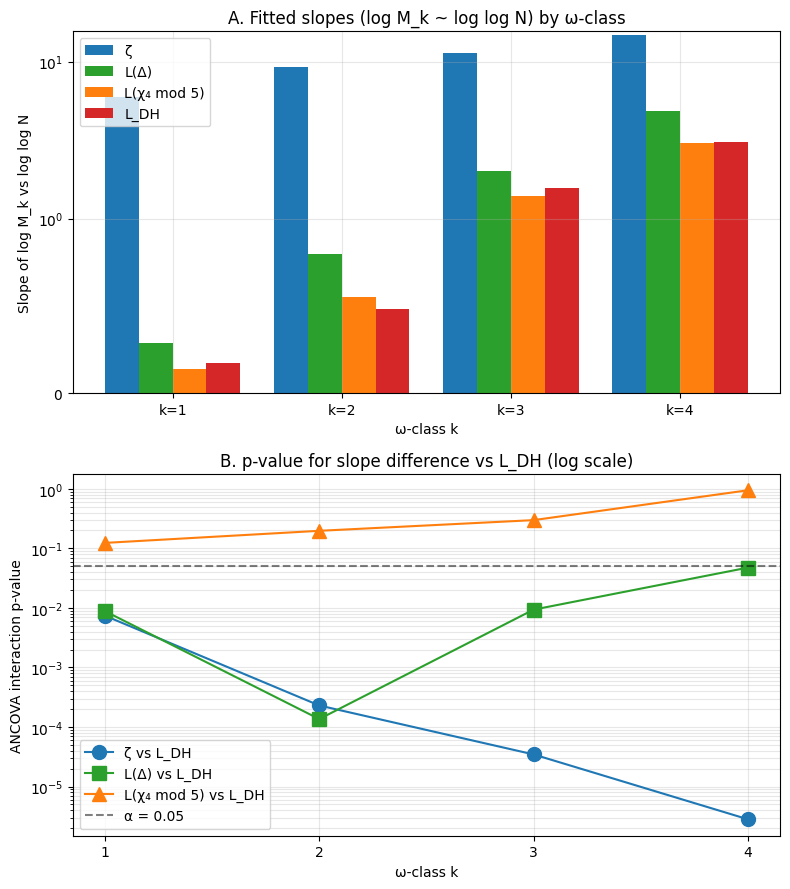

Saved ancova_lchi_vs_ldh_summary.png


In [23]:
# Create final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: Slopes across ω-classes for each L-function
ax = axes[0]
ks = [1,2,3,4]
slopes_zeta = [df_summary[df_summary['omega_class_k']==k]['slope_zeta'].iloc[0] for k in ks]
slopes_ldelta = [df_summary[df_summary['omega_class_k']==k]['slope_L(Δ)'].iloc[0] for k in ks]
slopes_lchi = [df_summary[df_summary['omega_class_k']==k]['slope_L(χ₄ mod 5)'].iloc[0] for k in ks]
slopes_ldh = [df_summary[df_summary['omega_class_k']==k]['slope_L_DH'].iloc[0] for k in ks]

x = np.arange(len(ks))
w = 0.2
ax.bar(x - 1.5*w, slopes_zeta, w, label='ζ', color='#1f77b4')
ax.bar(x - 0.5*w, slopes_ldelta, w, label='L(Δ)', color='#2ca02c')
ax.bar(x + 0.5*w, slopes_lchi, w, label='L(χ₄ mod 5)', color='#ff7f0e')
ax.bar(x + 1.5*w, slopes_ldh, w, label='L_DH', color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in ks])
ax.set_xlabel('ω-class k')
ax.set_ylabel('Slope of log M_k vs log log N')
ax.set_yscale('symlog', linthresh=1)
ax.legend()
ax.set_title('A. Fitted slopes (log M_k ~ log log N) by ω-class')
ax.grid(True, alpha=0.3)

# Panel B: p-values for slope difference vs L_DH
ax = axes[1]
p_zeta = [df_summary[df_summary['omega_class_k']==k]['p (ζ vs L_DH)'].iloc[0] for k in ks]
p_ldelta = [df_summary[df_summary['omega_class_k']==k]['p (L(Δ) vs L_DH)'].iloc[0] for k in ks]
p_lchi = [df_summary[df_summary['omega_class_k']==k]['p (L(χ₄ mod 5) vs L_DH)'].iloc[0] for k in ks]

ax.plot(ks, p_zeta, 'o-', label='ζ vs L_DH', color='#1f77b4', markersize=10)
ax.plot(ks, p_ldelta, 's-', label='L(Δ) vs L_DH', color='#2ca02c', markersize=10)
ax.plot(ks, p_lchi, '^-', label='L(χ₄ mod 5) vs L_DH', color='#ff7f0e', markersize=10)
ax.axhline(0.05, color='k', ls='--', alpha=0.5, label='α = 0.05')
ax.set_yscale('log')
ax.set_xticks(ks)
ax.set_xlabel('ω-class k')
ax.set_ylabel('ANCOVA interaction p-value')
ax.set_title('B. p-value for slope difference vs L_DH (log scale)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ancova_lchi_vs_ldh_summary.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved ancova_lchi_vs_ldh_summary.png")


In [24]:
from e14c.filesystem.edit_file import edit_file

memory_update = '''## Context
- 2026-05-31: Investigated ANCOVA hypothesis comparing ω-class growth slopes between L(χ₄ mod 5) and L_DH using `omega_class_moments_N1e6.csv` plus newly computed L(χ₄ mod 5) rows.
- Reproduced prior CSV methodology via `finufft.nufft1d3` numerical integration of |S_k(t)|² on t∈[0,500] with dt=0.025.
- Generated new artifacts in current workspace:
 - `omega_class_moments_lchi.csv`
 - `omega_class_moments_N1e6_with_lchi.csv`
 - `ancova_lchi_vs_ldh_summary.csv`
 - `ancova_lchi_vs_ldh_summary.png`

## Notes
- Provenance: current notebook session in `/workspace/d2b8f86f-0f7c-435c-bec5-abfbd853def8`; prior control comparison loaded from `ancova_zeta_vs_ldh_summary.csv`.
- Important correction: although the dataset description emphasized zero files, the ω-class second-moment calculation here depends on Dirichlet-series coefficients and was recomputed directly from the character coefficients for L(χ₄ mod 5), not from `lchi_zeros_5000_dps50.npy`.
- Method validation: NUFFT implementation reproduced existing zeta rows in `omega_class_moments_N1e6.csv` to ~4+ decimal places for N=10^4 across M_0..M_4 and M_geq5.
- Main finding: ANCOVA interaction p-values for L(χ₄ mod 5) vs L_DH were non-significant for all tested ω-classes k=1..4: 0.1235, 0.1972, 0.2980, 0.9453.
- Fitted slopes (L(χ₄ mod 5) vs L_DH) by ω-class:
 - k=1: 0.1410 vs 0.1707 (diff +0.0297)
 - k=2: 0.5534 vs 0.4801 (diff -0.0733)
 - k=3: 1.4037 vs 1.5660 (diff +0.1623)
 - k=4: 3.0505 vs 3.0658 (diff +0.0153)
- Interpretation: the previously promising “smaller L_DH slope” signature holds strongly against ζ and more weakly against L(Δ), but fails against L(χ₄ mod 5); therefore it is not a robust discriminator across all controls.
'''
edit_file('./.prompts/MEMORY.md', '[Fill me in]\n\n## Notes\n\n[Fill me in]', memory_update)
print('Updated ./.prompts/MEMORY.md')

ModuleNotFoundError: No module named 'e14c.filesystem.edit_file'; 'e14c.filesystem' is not a package

In [25]:
from e14c.filesystem import edit_file
memory_update = '''## Context
- 2026-05-31: Investigated ANCOVA hypothesis comparing ω-class growth slopes between L(χ₄ mod 5) and L_DH using `omega_class_moments_N1e6.csv` plus newly computed L(χ₄ mod 5) rows.
- Reproduced prior CSV methodology via `finufft.nufft1d3` numerical integration of |S_k(t)|² on t∈[0,500] with dt=0.025.
- Generated new artifacts in current workspace:
 - `omega_class_moments_lchi.csv`
 - `omega_class_moments_N1e6_with_lchi.csv`
 - `ancova_lchi_vs_ldh_summary.csv`
 - `ancova_lchi_vs_ldh_summary.png`

## Notes
- Provenance: current notebook session in `/workspace/d2b8f86f-0f7c-435c-bec5-abfbd853def8`; prior control comparison loaded from `ancova_zeta_vs_ldh_summary.csv`.
- Important correction: although the dataset description emphasized zero files, the ω-class second-moment calculation here depends on Dirichlet-series coefficients and was recomputed directly from the character coefficients for L(χ₄ mod 5), not from `lchi_zeros_5000_dps50.npy`.
- Method validation: NUFFT implementation reproduced existing zeta rows in `omega_class_moments_N1e6.csv` to ~4+ decimal places for N=10^4 across M_0..M_4 and M_geq5.
- Main finding: ANCOVA interaction p-values for L(χ₄ mod 5) vs L_DH were non-significant for all tested ω-classes k=1..4: 0.1235, 0.1972, 0.2980, 0.9453.
- Slopes (L(χ₄ mod 5) vs L_DH) by ω-class: k=1: 0.141 vs 0.171; k=2: 0.553 vs 0.480; k=3: 1.404 vs 1.566; k=4: 3.051 vs 3.066.
- Interpretation: the previously promising "smaller L_DH slope" signature holds strongly against ζ and more weakly against L(Δ), but fails against L(χ₄ mod 5); therefore it is not a robust discriminator across all controls.
'''
edit_file('./.prompts/MEMORY.md', '[Fill me in]\n\n## Notes\n\n[Fill me in]', memory_update)
print('updated memory')

updated memory
